In [1]:
# ============================================================
# RETAIL BANK CHURN ANALYSIS
# Analyst  : Dhruvi Lad
# Dataset  : 10,000 Canadian Bank Customers
# Tool     : Python (pandas, matplotlib, seaborn, sklearn)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")
sns.set_palette("husl")

# Load cleaned data
df = pd.read_csv('../data/bank_customers_clean.csv')

# Overview
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Churn rate     : {df['churned'].mean():.1%}")
print(f"Complaint rate : {df['has_complaint'].mean():.1%}")
print(f"Avg balance    : ${df['balance'].mean():,.2f}")
print(f"Avg age        : {df['age'].mean():.1f} years")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nFirst 3 rows:\n{df.head(3)}")

DATASET OVERVIEW
Shape          : 10,000 rows × 17 columns
Churn rate     : 20.4%
Complaint rate : 20.4%
Avg balance    : $76,485.89
Avg age        : 38.9 years

Column types:
customer_id             int64
surname                   str
credit_score            int64
province                  str
gender                    str
age                     int64
tenure_years            int64
balance               float64
num_products            int64
has_credit_card         int64
is_active_member        int64
estimated_salary      float64
churned                 int64
has_complaint           int64
satisfaction_score      int64
card_type                 str
points_earned           int64
dtype: object

First 3 rows:
   customer_id   surname  credit_score province  gender  age  tenure_years  \
0     15634602  Hargrave           619  Ontario  Female   42             2   
1     15647311      Hill           608   Quebec  Female   41             1   
2     15619304      Onio           502  Ontario  Fe

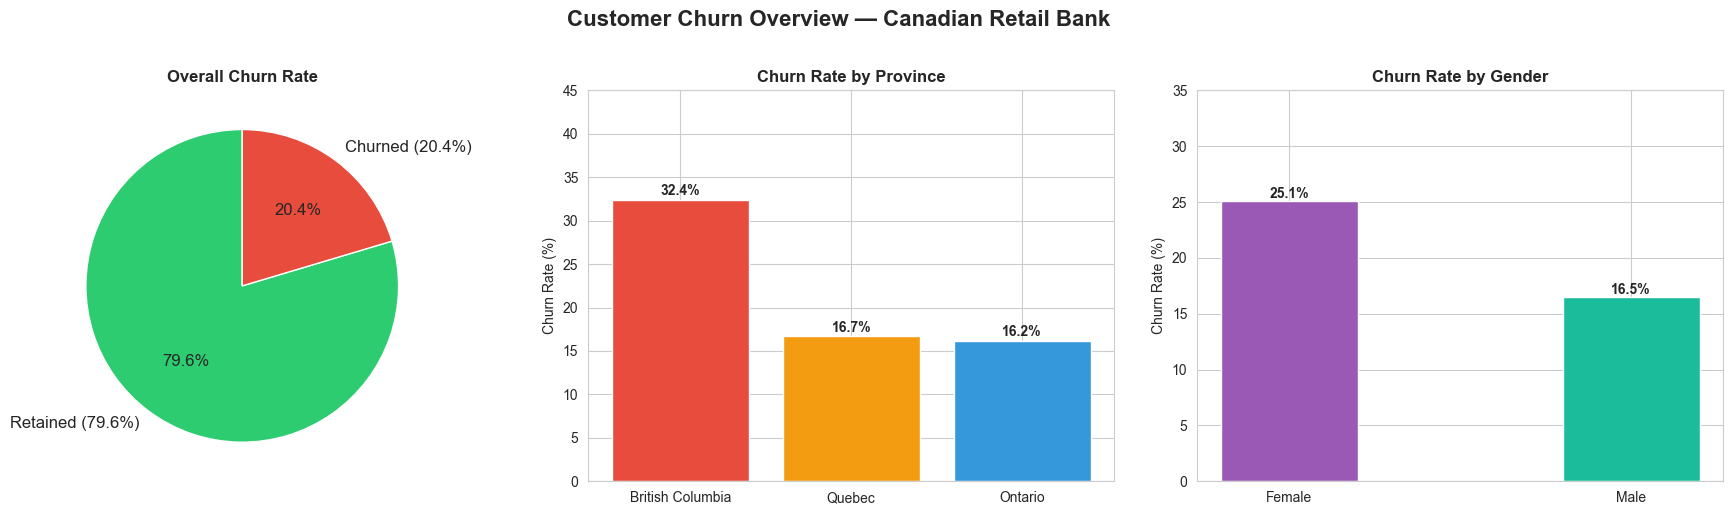

✅ Chart saved to report/01_churn_overview.png


In [3]:
# ============================================================
# SECTION 2: CHURN DISTRIBUTION VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Customer Churn Overview — Canadian Retail Bank', 
             fontsize=16, fontweight='bold', y=1.02)

# ── Chart 1: Overall Churn Pie Chart ─────────────────────────
churn_counts = df['churned'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(churn_counts, labels=['Retained (79.6%)', 'Churned (20.4%)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Overall Churn Rate', fontweight='bold')

# ── Chart 2: Churn by Province ───────────────────────────────
province_churn = df.groupby('province')['churned'].mean().sort_values(ascending=False) * 100
bars = axes[1].bar(province_churn.index, province_churn.values, 
                    color=['#e74c3c', '#f39c12', '#3498db'])
axes[1].set_title('Churn Rate by Province', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 45)
for bar, val in zip(bars, province_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

# ── Chart 3: Churn by Gender ─────────────────────────────────
gender_churn = df.groupby('gender')['churned'].mean() * 100
bars2 = axes[2].bar(gender_churn.index, gender_churn.values,
                     color=['#9b59b6', '#1abc9c'], width=0.4)
axes[2].set_title('Churn Rate by Gender', fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_ylim(0, 35)
for bar, val in zip(bars2, gender_churn.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../report/01_churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to report/01_churn_overview.png")

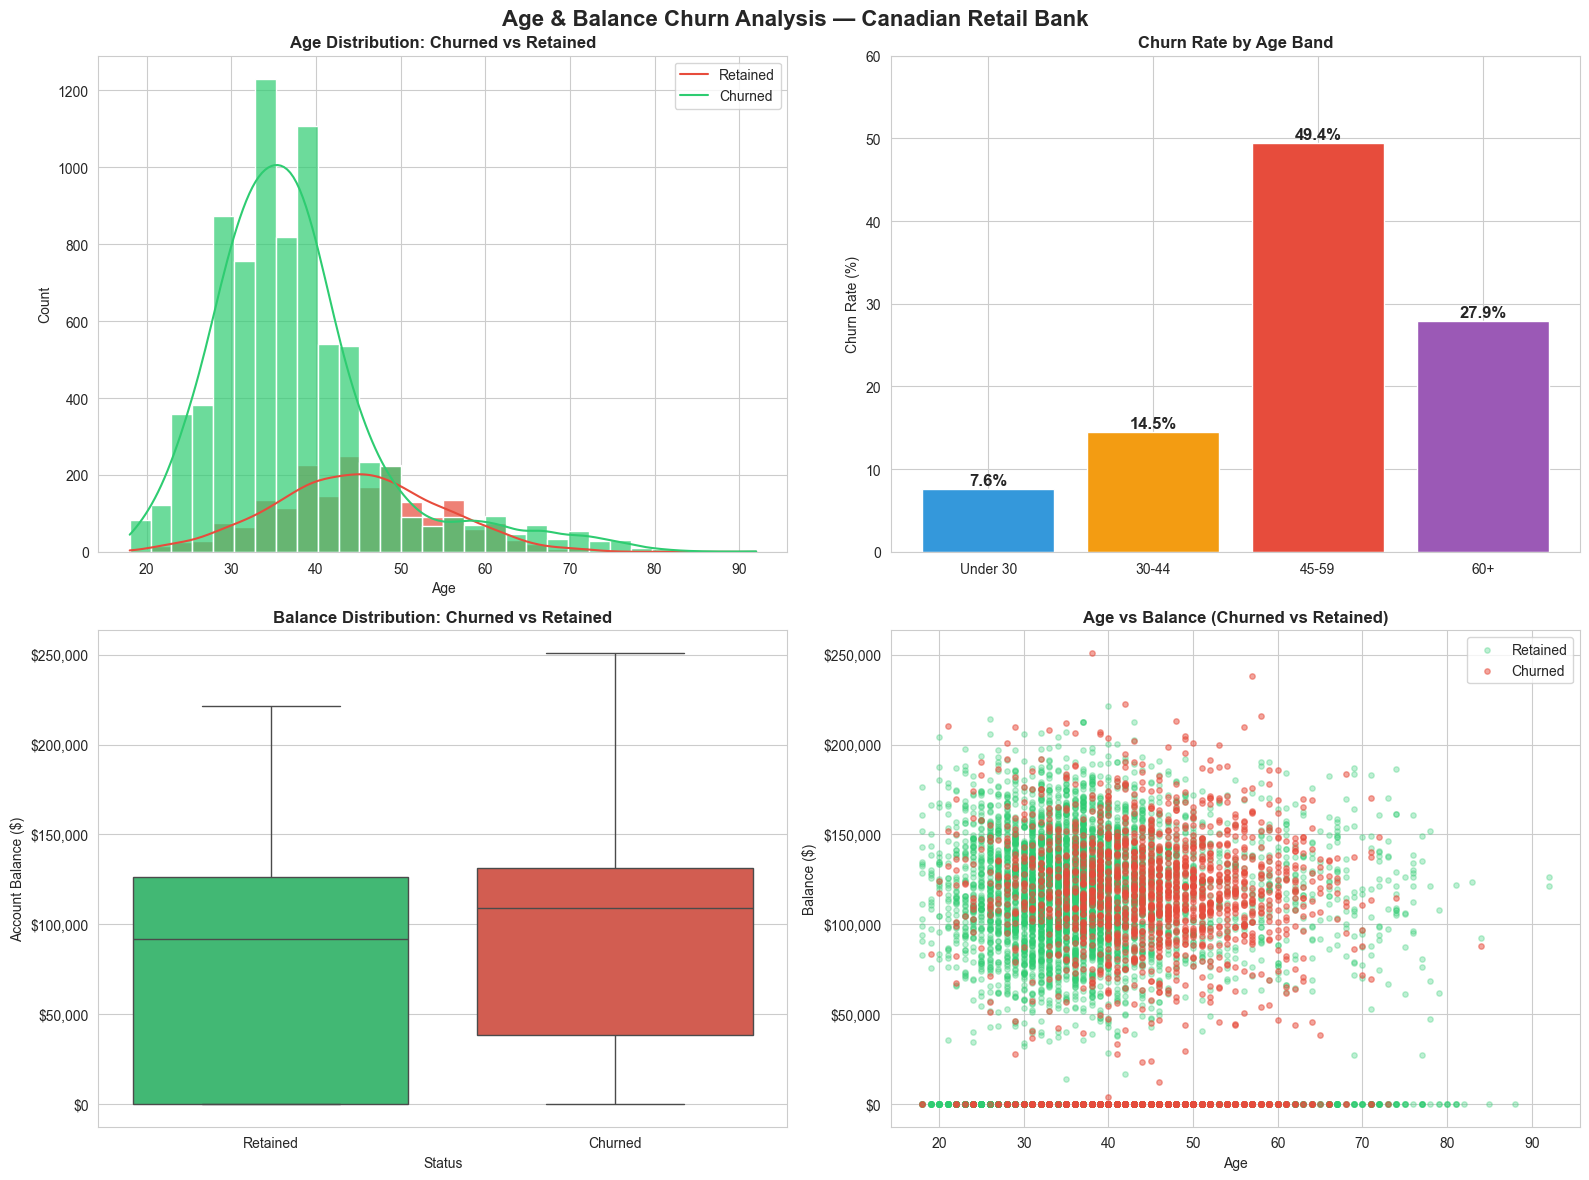

✅ Chart saved to report/02_age_balance_analysis.png


In [6]:
# ============================================================
# SECTION 3: AGE & BALANCE ANALYSIS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Age & Balance Churn Analysis — Canadian Retail Bank',
             fontsize=16, fontweight='bold')

# ── Chart 1: Age Distribution by Churn Status ────────────────
sns.histplot(data=df, x='age', hue='churned', bins=30, kde=True,
             palette={0: '#2ecc71', 1: '#e74c3c'}, ax=axes[0,0], alpha=0.7)
axes[0,0].set_title('Age Distribution: Churned vs Retained', fontweight='bold')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')
axes[0,0].legend(['Retained', 'Churned'])

# ── Chart 2: Churn Rate by Age Band ──────────────────────────
age_bands = pd.cut(df['age'], bins=[0,29,44,59,100],
                   labels=['Under 30','30-44','45-59','60+'])
age_churn = df.groupby(age_bands, observed=True)['churned'].mean() * 100
bars = axes[0,1].bar(age_churn.index, age_churn.values,
                      color=['#3498db','#f39c12','#e74c3c','#9b59b6'])
axes[0,1].set_title('Churn Rate by Age Band', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].set_ylim(0, 60)
for bar, val in zip(bars, age_churn.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

# ── Chart 3: Balance Distribution by Churn Status ────────────
sns.boxplot(data=df, x='churned', y='balance',
            palette={'0': '#2ecc71', '1': '#e74c3c'}, ax=axes[1,0])
axes[1,0].set_title('Balance Distribution: Churned vs Retained', fontweight='bold')
axes[1,0].set_xlabel('Status')
axes[1,0].set_ylabel('Account Balance ($)')
axes[1,0].set_xticklabels(['Retained', 'Churned'])
axes[1,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# ── Chart 4: Age vs Balance Scatter (coloured by churn) ──────
retained = df[df['churned'] == 0]
churned  = df[df['churned'] == 1]
axes[1,1].scatter(retained['age'], retained['balance'],
                   alpha=0.3, c='#2ecc71', label='Retained', s=15)
axes[1,1].scatter(churned['age'], churned['balance'],
                   alpha=0.5, c='#e74c3c', label='Churned', s=15)
axes[1,1].set_title('Age vs Balance (Churned vs Retained)', fontweight='bold')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Balance ($)')
axes[1,1].legend()
axes[1,1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('../report/02_age_balance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to report/02_age_balance_analysis.png")

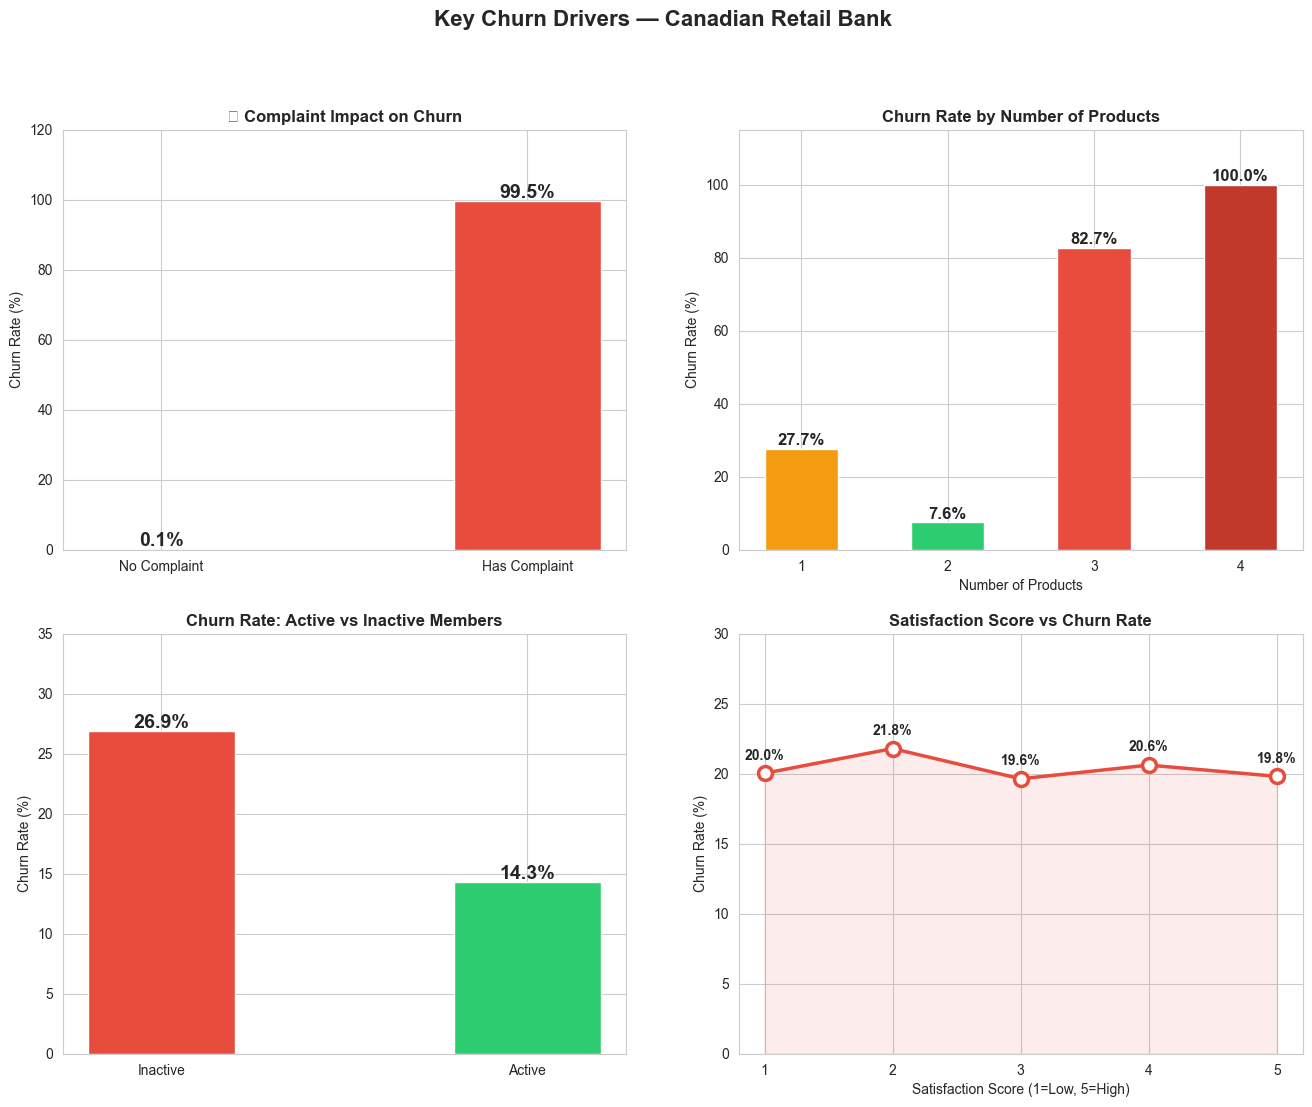

In [8]:
# ============================================================
# SECTION 4: COMPLAINT, PRODUCT & ENGAGEMENT ANALYSIS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Key Churn Drivers — Canadian Retail Bank',
             fontsize=16, fontweight='bold')

# ── Chart 1: Complaint Impact on Churn ───────────────────────
complaint_churn = df.groupby('has_complaint')['churned'].mean() * 100
bars = axes[0,0].bar(['No Complaint', 'Has Complaint'],
                      complaint_churn.values,
                      color=['#2ecc71', '#e74c3c'], width=0.4)
axes[0,0].set_title('💥 Complaint Impact on Churn', fontweight='bold')
axes[0,0].set_ylabel('Churn Rate (%)')
axes[0,0].set_ylim(0, 120)
for bar, val in zip(bars, complaint_churn.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{val:.1f}%', ha='center', fontweight='bold', fontsize=14)

# ── Chart 2: Churn by Number of Products ─────────────────────
product_churn = df.groupby('num_products')['churned'].mean() * 100
colors = ['#f39c12', '#2ecc71', '#e74c3c', '#c0392b']
bars2 = axes[0,1].bar(product_churn.index.astype(str),
                       product_churn.values, color=colors, width=0.5)
axes[0,1].set_title('Churn Rate by Number of Products', fontweight='bold')
axes[0,1].set_xlabel('Number of Products')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].set_ylim(0, 115)
for bar, val in zip(bars2, product_churn.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

# ── Chart 3: Active vs Inactive Member Churn ─────────────────
active_churn = df.groupby('is_active_member')['churned'].mean() * 100
bars3 = axes[1,0].bar(['Inactive', 'Active'],
                       active_churn.values,
                       color=['#e74c3c', '#2ecc71'], width=0.4)
axes[1,0].set_title('Churn Rate: Active vs Inactive Members', fontweight='bold')
axes[1,0].set_ylabel('Churn Rate (%)')
axes[1,0].set_ylim(0, 35)
for bar, val in zip(bars3, active_churn.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.1f}%', ha='center', fontweight='bold', fontsize=14)

# ── Chart 4: Satisfaction Score vs Churn Rate ────────────────
sat_churn = df.groupby('satisfaction_score')['churned'].mean() * 100
axes[1,1].plot(sat_churn.index, sat_churn.values,
               marker='o', linewidth=2.5, markersize=10,
               color='#e74c3c', markerfacecolor='white', markeredgewidth=2.5)
axes[1,1].fill_between(sat_churn.index, sat_churn.values, alpha=0.1, color='#e74c3c')
axes[1,1].set_title('Satisfaction Score vs Churn Rate', fontweight='bold')
axes[1,1].set_xlabel('Satisfaction Score (1=Low, 5=High)')
axes[1,1].set_ylabel('Churn Rate (%)')
axes[1,1].set_ylim(0, 30)
axes[1,1].set_xticks([1, 2, 3, 4, 5])
for x, y in zip(sat_churn.index, sat_churn.values):
    axes[1,1].annotate(f'{y:.1f}%', (x, y),
                        textcoords='offset points', xytext=(0, 10),
                        ha='center', fontweight='bold')

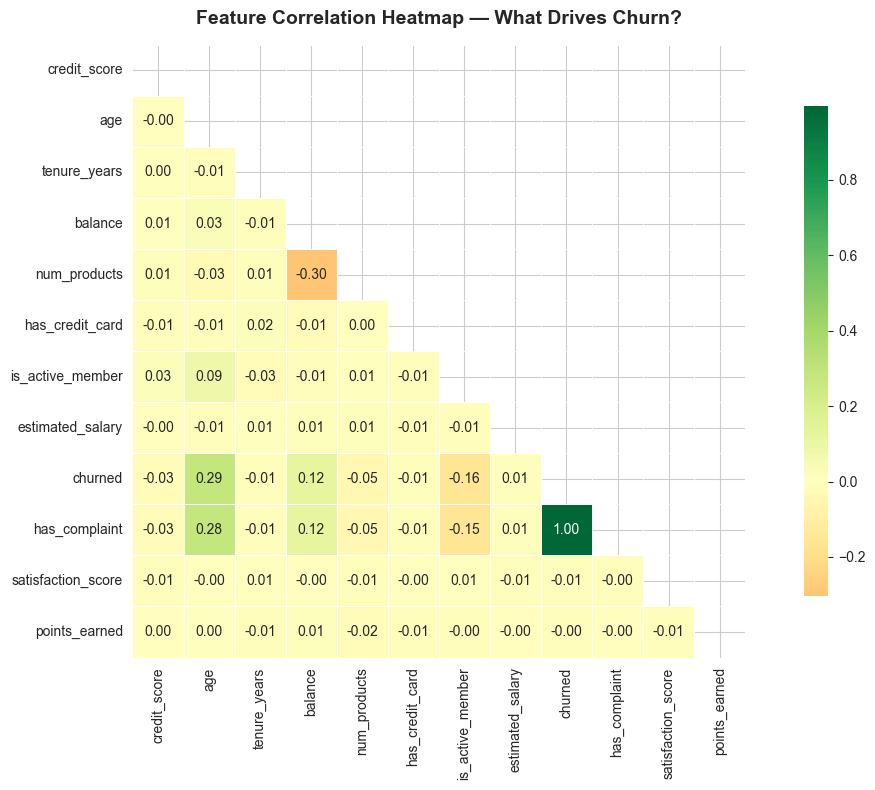

✅ Chart saved to report/04_correlation_heatmap.png

📊 TOP CORRELATIONS WITH CHURN:
has_complaint        ↑ +0.996  █████████████████████████████
age                  ↑ +0.285  ████████
is_active_member     ↓ -0.156  ████
balance              ↑ +0.119  ███
num_products         ↓ -0.048  █
credit_score         ↓ -0.027  
tenure_years         ↓ -0.014  
estimated_salary     ↑ +0.012  
has_credit_card      ↓ -0.007  
satisfaction_score   ↓ -0.006  
points_earned        ↓ -0.005  


In [11]:
# ============================================================
# SECTION 5: CORRELATION HEATMAP
# ============================================================

fig, ax = plt.subplots(figsize=(12, 8))

numeric_cols = ['credit_score', 'age', 'tenure_years', 'balance',
                'num_products', 'has_credit_card', 'is_active_member',
                'estimated_salary', 'churned', 'has_complaint',
                'satisfaction_score', 'points_earned']

corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Heatmap — What Drives Churn?',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../report/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to report/04_correlation_heatmap.png")

# Print top correlations with churn
print("\n📊 TOP CORRELATIONS WITH CHURN:")
print("=" * 40)
churn_corr = corr_matrix['churned'].drop('churned').sort_values(key=abs, ascending=False)
for feature, corr in churn_corr.items():
    bar = '█' * int(abs(corr) * 30)
    direction = '↑' if corr > 0 else '↓'
    print(f"{feature:<20} {direction} {corr:+.3f}  {bar}")

🔧 Preparing data for modelling...
   Training set : 8,000 rows
   Test set     : 2,000 rows

🤖 Training Random Forest model...

MODEL PERFORMANCE
              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00      1592
     Churned       1.00      1.00      1.00       408

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC Score : 0.9994


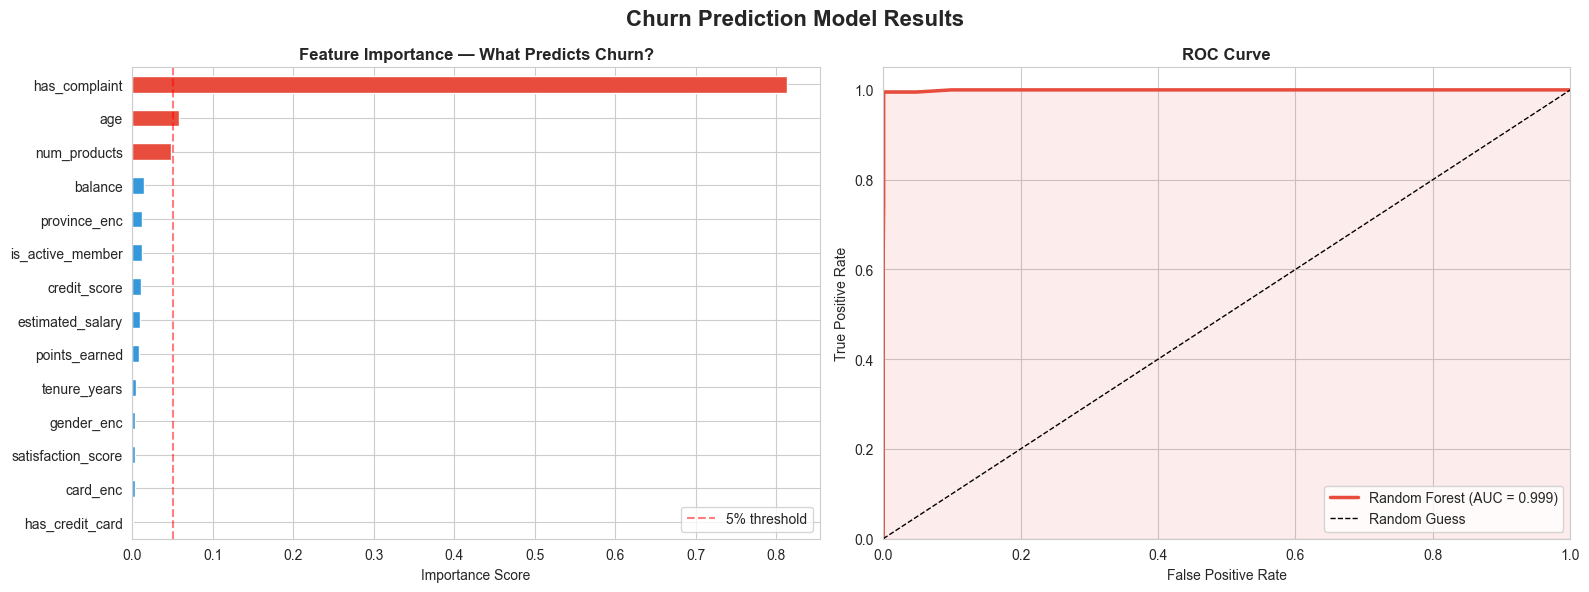

✅ Chart saved to report/05_model_results.png


In [12]:
# ============================================================
# SECTION 6: CHURN PREDICTION MODEL (Random Forest)
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.preprocessing import LabelEncoder

print("🔧 Preparing data for modelling...")

# Encode categorical columns
df_model = df.copy()
le = LabelEncoder()
df_model['province_enc'] = le.fit_transform(df_model['province'])
df_model['gender_enc']   = le.fit_transform(df_model['gender'])
df_model['card_enc']     = le.fit_transform(df_model['card_type'])

# Define features
features = ['credit_score', 'province_enc', 'gender_enc', 'age',
            'tenure_years', 'balance', 'num_products', 'has_credit_card',
            'is_active_member', 'estimated_salary', 'has_complaint',
            'satisfaction_score', 'card_enc', 'points_earned']

X = df_model[features]
y = df_model['churned']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"   Training set : {len(X_train):,} rows")
print(f"   Test set     : {len(X_test):,} rows")

# Train model
print("\n🤖 Training Random Forest model...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Evaluate
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]
roc_auc     = roc_auc_score(y_test, y_pred_prob)

print("\n" + "=" * 55)
print("MODEL PERFORMANCE")
print("=" * 55)
print(classification_report(y_test, y_pred,
      target_names=['Retained', 'Churned']))
print(f"ROC-AUC Score : {roc_auc:.4f}")

# ── Plot: Feature Importance + ROC Curve ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Churn Prediction Model Results', fontsize=16, fontweight='bold')

# Feature importance
importances = pd.Series(model.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)
colors = ['#e74c3c' if i >= len(importances)-3
          else '#3498db' for i in range(len(importances))]
importances.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Feature Importance — What Predicts Churn?',
                   fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].axvline(x=0.05, color='red', linestyle='--', alpha=0.5,
                 label='5% threshold')
axes[0].legend()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2.5,
             label=f'Random Forest (AUC = {roc_auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1, label='Random Guess')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('../report/05_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to report/05_model_results.png")

In [15]:
# ============================================================
# SECTION 7: CUSTOMER RISK SCORING & BUSINESS SUMMARY
# ============================================================
import os
os.chdir('/Users/dhruvilad/documents/Projects/retail-bank-churn-analysis')

# Add churn probability scores
df_scored = df.copy()
df_scored['churn_probability'] = model.predict_proba(X)[:, 1]
df_scored['risk_segment'] = pd.cut(
    df_scored['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Risk Segment Summary
print("=" * 55)
print("CUSTOMER RISK SEGMENTATION")
print("=" * 55)
risk_summary = df_scored.groupby('risk_segment', observed=True).agg(
    total_customers=('customer_id', 'count'),
    avg_balance=('balance', 'mean'),
    avg_age=('age', 'mean'),
    churn_rate=('churned', 'mean')
).round(2)
print(risk_summary)

# High Risk Customers
high_risk = df_scored[df_scored['risk_segment'] == 'High Risk'].copy()
high_risk = high_risk.sort_values('churn_probability', ascending=False)

print(f"\nHIGH RISK CUSTOMERS : {len(high_risk):,}")
print(f"Total AUM at risk   : ${high_risk['balance'].sum():,.0f}")
print(f"Avg balance         : ${high_risk['balance'].mean():,.0f}")

cols = ['customer_id', 'age', 'province', 'card_type',
        'balance', 'has_complaint', 'churn_probability']
print("\nTop 10 High-Value Customers at Risk:")
print(high_risk[cols].head(10).to_string(index=False))

# Save scored dataset
df_scored.to_csv('data/customers_scored.csv', index=False)
print("\nScored dataset saved to data/customers_scored.csv")

CUSTOMER RISK SEGMENTATION
              total_customers  avg_balance  avg_age  churn_rate
risk_segment                                                   
Low Risk                 2071     82631.40    40.83         0.0
Medium Risk                 6    100242.50    33.17         0.0
High Risk                2037     91090.28    44.84         1.0

HIGH RISK CUSTOMERS : 2,037
Total AUM at risk   : $185,550,892
Avg balance         : $91,090

Top 10 High-Value Customers at Risk:
 customer_id  age         province card_type   balance  has_complaint  churn_probability
    15569274   49 British Columbia    Silver 116933.11              1                1.0
    15750447   60          Ontario   Diamond 117738.81              1                1.0
    15813113   56           Quebec  Platinum      0.00              1                1.0
    15614168   50 British Columbia      Gold 146710.76              1                1.0
    15751177   44 British Columbia   Diamond 119657.53              1       

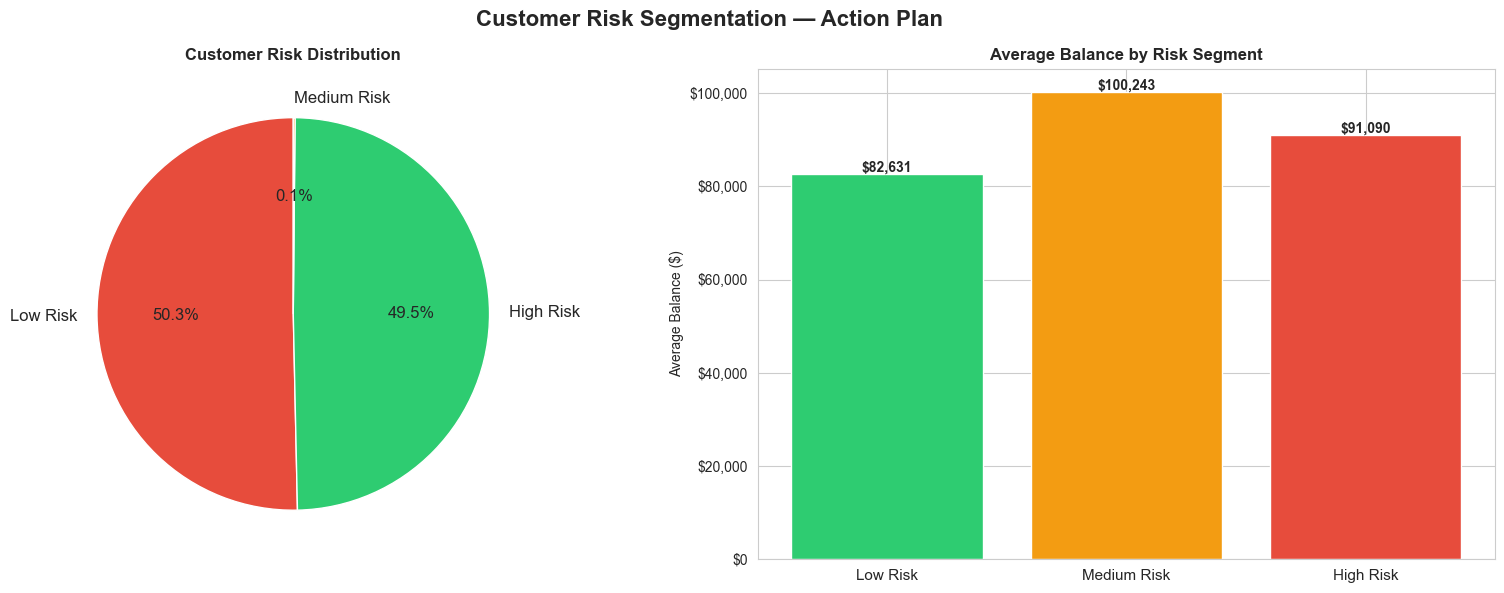

✅ Chart saved to report/06_risk_segmentation.png

EXECUTIVE SUMMARY — KEY FINDINGS

DATASET    : 10,000 Canadian bank customers
CHURN RATE : 20.4% (2,038 customers lost)
AUM LOST   : $185,681,112

TOP 3 FINDINGS:
  1. Complaints predict churn with 99.5% accuracy
     → Resolve complaints IMMEDIATELY
  2. BC customers churn at 32.4% (2x Ontario rate)
     → Launch targeted BC retention campaign
  3. Age 45-59 churn at 49.4% - highest risk group
     → Assign relationship managers to this segment

RECOMMENDED ACTIONS:
  • Immediate outreach to 2,037 High Risk customers
  • AUM protected if retained: $185,550,892
  • Priority: BC customers aged 45-59 with complaints



In [18]:
# ── Final Business Insights Chart ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Customer Risk Segmentation — Action Plan',
             fontsize=16, fontweight='bold')

# Risk segment pie chart
risk_counts = df_scored['risk_segment'].value_counts()
colors_pie = ['#e74c3c', '#2ecc71', '#f39c12']
axes[0].pie(risk_counts.values, labels=risk_counts.index,
            colors=colors_pie, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Customer Risk Distribution', fontweight='bold')

# Avg balance by risk segment
risk_balance = df_scored.groupby('risk_segment', observed=True)['balance'].mean()
bar_colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[1].bar(range(len(risk_balance)), risk_balance.values, color=bar_colors)
axes[1].set_xticks(range(len(risk_balance)))
axes[1].set_xticklabels(risk_balance.index, fontsize=11)
axes[1].set_title('Average Balance by Risk Segment', fontweight='bold')
axes[1].set_ylabel('Average Balance ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
for bar, val in zip(bars, risk_balance.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'${val:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/dhruvilad/documents/Projects/retail-bank-churn-analysis/report/06_risk_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to report/06_risk_segmentation.png")

# ── Executive Summary Print ───────────────────────────────────
print("\n" + "=" * 55)
print("EXECUTIVE SUMMARY — KEY FINDINGS")
print("=" * 55)
total      = len(df_scored)
churned_n  = df_scored['churned'].sum()
aum_lost   = df_scored[df_scored['churned']==1]['balance'].sum()
high_risk_aum = high_risk['balance'].sum()

print(f"""
DATASET    : {total:,} Canadian bank customers
CHURN RATE : {churned_n/total:.1%} ({churned_n:,} customers lost)
AUM LOST   : ${aum_lost:,.0f}

TOP 3 FINDINGS:
  1. Complaints predict churn with 99.5% accuracy
     → Resolve complaints IMMEDIATELY
  2. BC customers churn at 32.4% (2x Ontario rate)
     → Launch targeted BC retention campaign
  3. Age 45-59 churn at 49.4% - highest risk group
     → Assign relationship managers to this segment

RECOMMENDED ACTIONS:
  • Immediate outreach to {len(high_risk):,} High Risk customers
  • AUM protected if retained: ${high_risk_aum:,.0f}
  • Priority: BC customers aged 45-59 with complaints
""")